In [1]:
from simple_unet import multi_unet_model
from keras.utils import normalize
import os
import glob
import cv2
import numpy as np
from matplotlib import pyplot as plt
import sys
import random

np.set_printoptions(threshold=sys.maxsize)

In [ ]:
#Resizing images
SIZE_X = 640
SIZE_Y = 640
n_classes= 9 # Number of classes for segmentation
#path for training images
TRAIN_PATH_X = 'F://Fibergram Segmentation Module//request_form_github//X' #raw image
TRAIN_PATH_Y = 'F://Fibergram Segmentation Module//request_form_github//Y' #mask

train_ids_x = next(os.walk(TRAIN_PATH_X))[2]
train_ids_y = next(os.walk(TRAIN_PATH_Y))[2]

In [3]:
#Capture training image info as a list
train_images = []

for directory_path in glob.glob(TRAIN_PATH_X):
    for img_path in glob.glob(os.path.join(directory_path, "*.jpeg")):
        img = cv2.imread(img_path, 0)       
        img = cv2.resize(img, (SIZE_Y, SIZE_X))
        train_images.append(img)    

#Convert list to array for machine learning processing        
train_images = np.array(train_images)

In [4]:
#Capture mask/label info as a list
train_masks = [] 
for directory_path in glob.glob(TRAIN_PATH_Y):
    for mask_path in glob.glob(os.path.join(directory_path, "*.jpeg")):
        mask = cv2.imread(mask_path, 0)       
        mask = cv2.resize(mask, (SIZE_Y, SIZE_X), interpolation = cv2.INTER_NEAREST)  #Otherwise ground truth changes due to interpolation
        train_masks.append(mask)
        
#Convert list to array for machine learning processing          
train_masks = np.array(train_masks)

In [5]:
train_masks[train_masks == 16] = 106
train_masks[train_masks == 24] = 106
train_masks[train_masks == 41] = 106
train_masks[train_masks == 74] = 106
train_masks[train_masks == 139] = 106
train_masks[train_masks == 180] = 106
np.unique(train_masks)

array([  0, 106, 255], dtype=uint8)

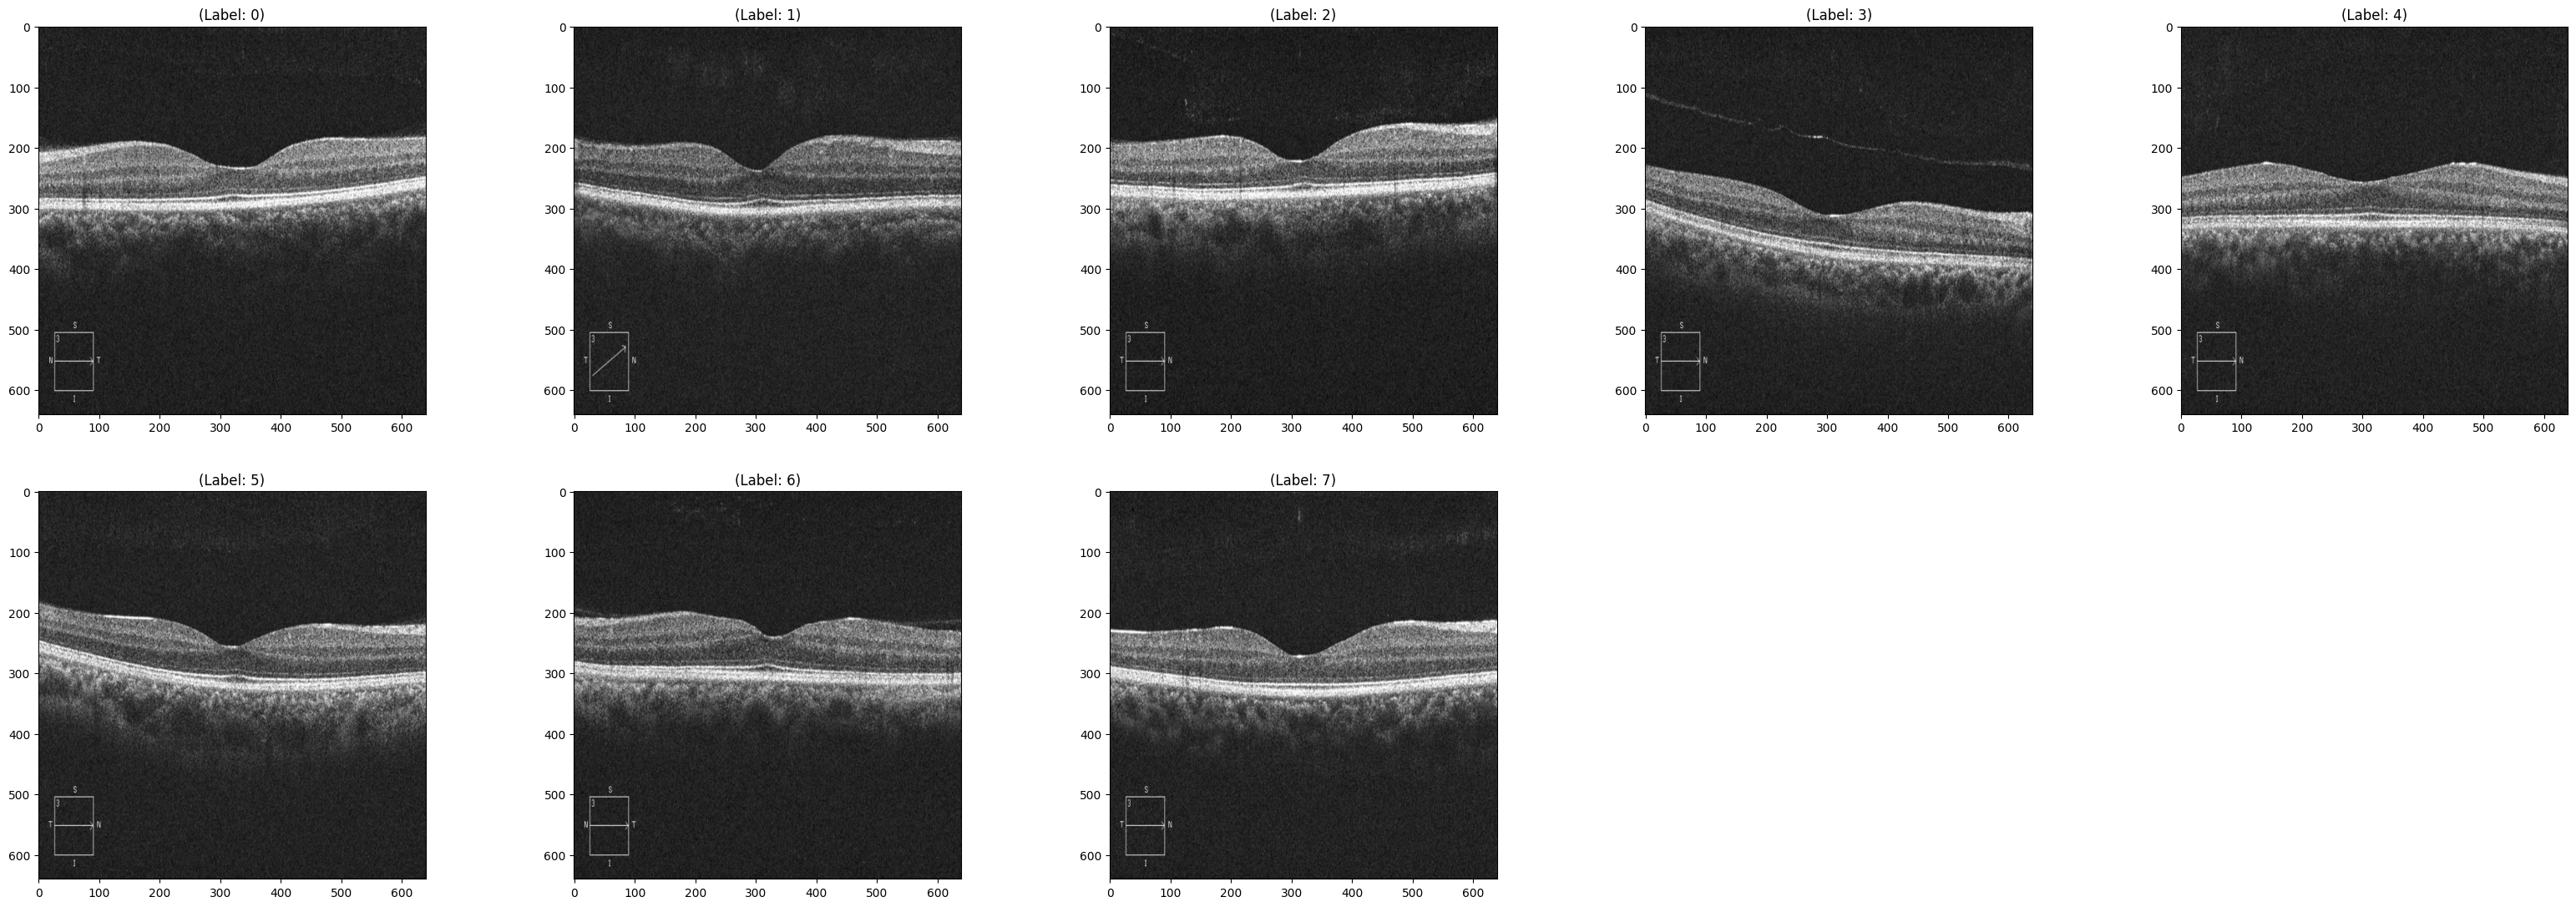

In [6]:
plt.figure(figsize=(40,100))
for i in range(8):
    plt.subplot(14, 5, i+1)
    plt.imshow(train_images[i,:,:],cmap='gray')
    plt.title("(Label: " + str(i) + ")")
plt.show()   

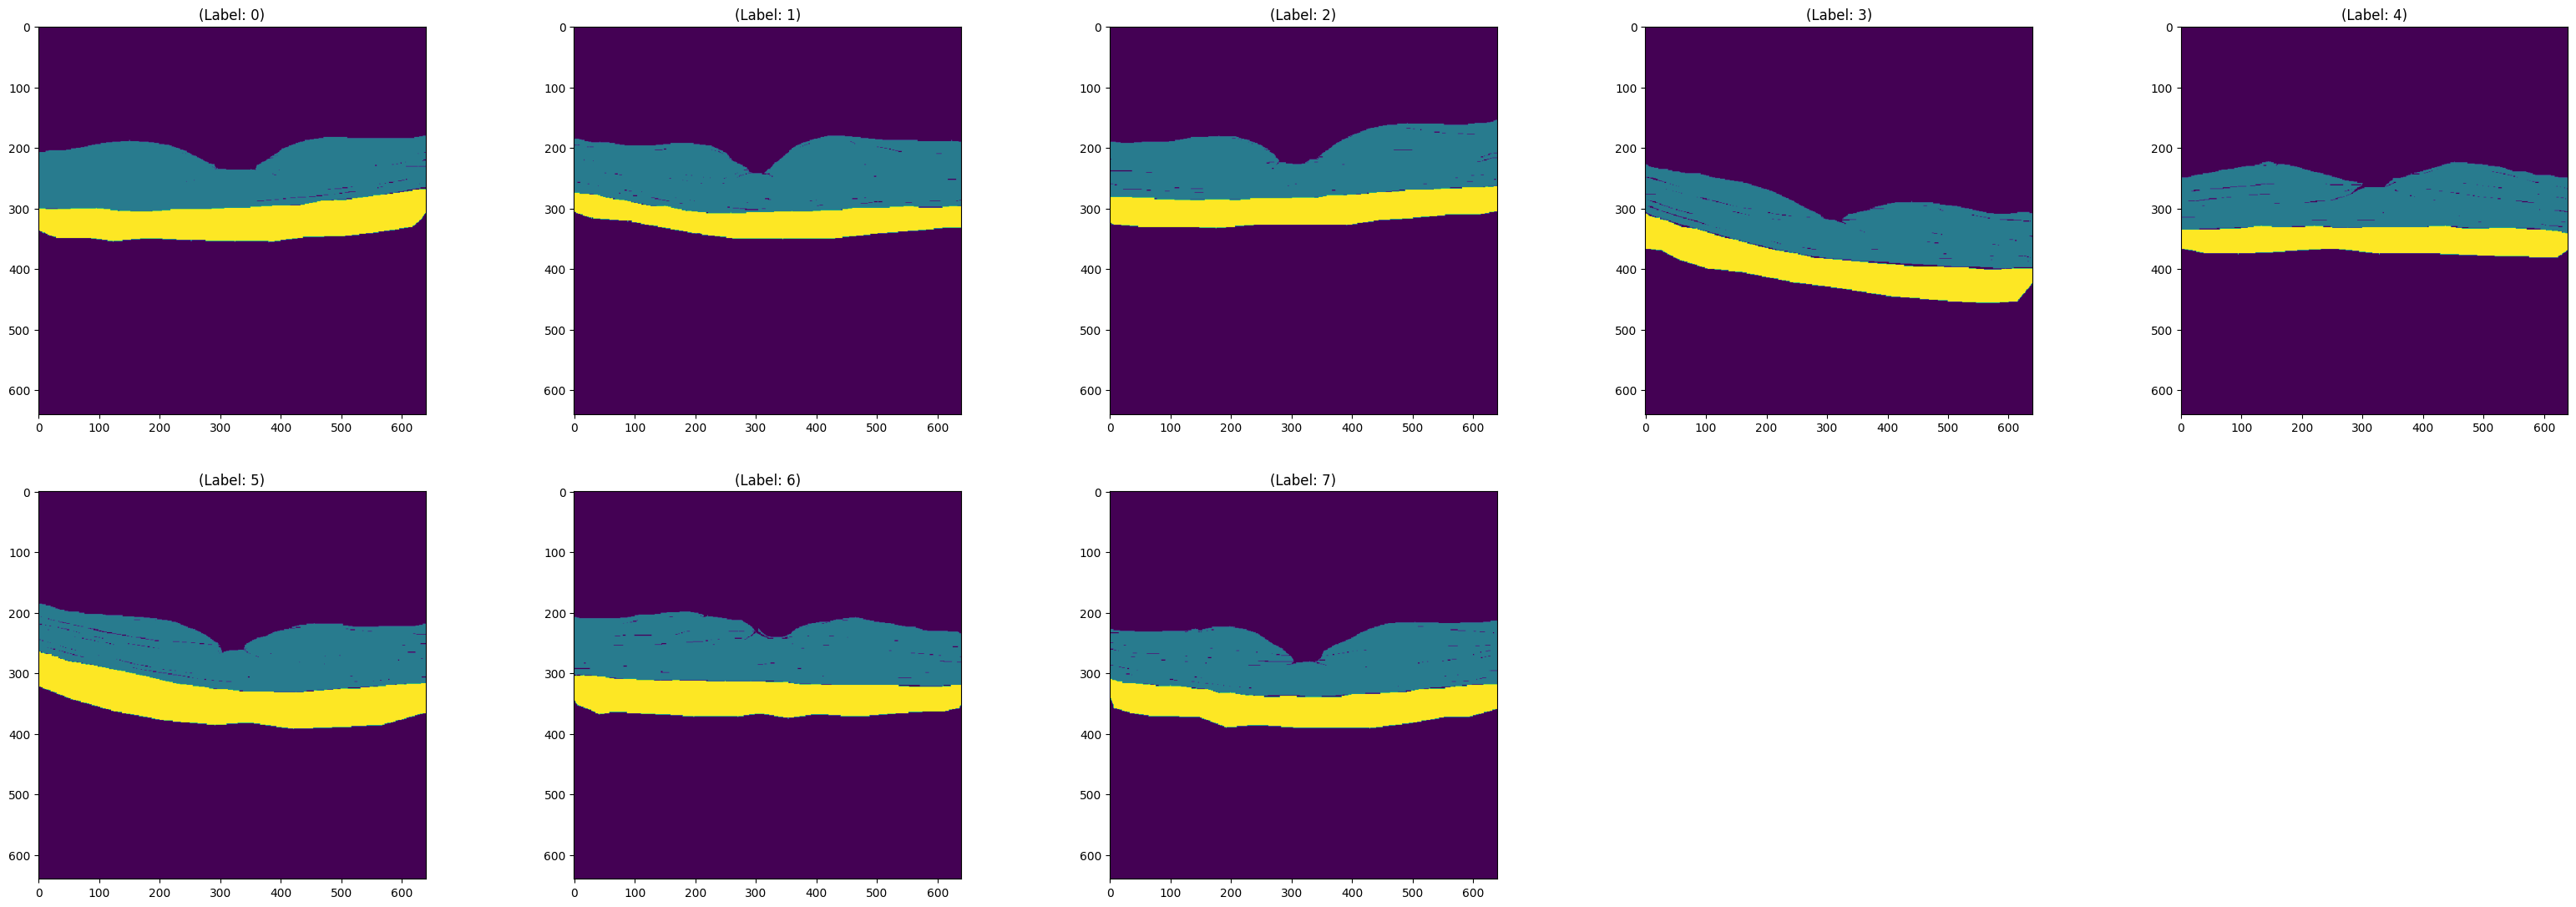

In [7]:
plt.figure(figsize=(40,100))
for i in range(8):
    plt.subplot(14, 5, i+1)
    plt.imshow(train_masks[i,:,:])
    plt.title("(Label: " + str(i) + ")")
plt.show()   

In [8]:
#Encode labels
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
n, h, w = train_masks.shape
train_masks_reshaped = train_masks.reshape(-1,1)
train_masks_reshaped_encoded = labelencoder.fit_transform(train_masks_reshaped)
train_masks_encoded_original_shape = train_masks_reshaped_encoded.reshape(n, h, w)

np.unique(train_masks_encoded_original_shape)

train_images = np.expand_dims(train_images, axis=3)
train_images = normalize(train_images, axis=1)

train_masks_input = np.expand_dims(train_masks_encoded_original_shape, axis=3)


c:\Users\FOIL_member\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [9]:

#Create a subset of data for quick testing
#Picking 10% for testing and remaining for training
from sklearn.model_selection import train_test_split
X1, X_test, y1, y_test = train_test_split(train_images, train_masks_input, test_size = 0.10, random_state = 0)

#Further split training data t a smaller subset for quick testing of models
X_train, X_do_not_use, y_train, y_do_not_use = train_test_split(X1, y1, test_size = 0.2, random_state = 0)

print("Class values in the dataset are ... ", np.unique(y_train))  # 0 is the background/few unlabeled 


Class values in the dataset are ...  [0 1 2]


In [12]:
from keras.utils import to_categorical
train_masks_cat = to_categorical(y_train, num_classes=n_classes)
y_train_cat = train_masks_cat.reshape((y_train.shape[0], y_train.shape[1], y_train.shape[2], n_classes))



test_masks_cat = to_categorical(y_test, num_classes=n_classes)
y_test_cat = test_masks_cat.reshape((y_test.shape[0], y_test.shape[1], y_test.shape[2], n_classes))


IMG_HEIGHT = X_train.shape[1]
IMG_WIDTH  = X_train.shape[2]
IMG_CHANNELS = X_train.shape[3]

In [13]:
def get_model():
    return multi_unet_model(n_classes=n_classes, IMG_HEIGHT=SIZE_Y, IMG_WIDTH=SIZE_X, IMG_CHANNELS=1)

model = get_model()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 640, 640, 1)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 640, 640, 16)         160       ['input_1[0][0]']             
                                                                                                  
 dropout (Dropout)           (None, 640, 640, 16)         0         ['conv2d[0][0]']              
                                                                                                  
 conv2d_1 (Conv2D)           (None, 640, 640, 16)         2320      ['dropout[0][0]']             
                                                                                              

 conv2d_transpose_3 (Conv2D  (None, 640, 640, 16)         2064      ['conv2d_15[0][0]']           
 Transpose)                                                                                       
                                                                                                  
 concatenate_3 (Concatenate  (None, 640, 640, 32)         0         ['conv2d_transpose_3[0][0]',  
 )                                                                   'conv2d_1[0][0]']            
                                                                                                  
 conv2d_16 (Conv2D)          (None, 640, 640, 16)         4624      ['concatenate_3[0][0]']       
                                                                                                  
 dropout_8 (Dropout)         (None, 640, 640, 16)         0         ['conv2d_16[0][0]']           
                                                                                                  
 conv2d_17

In [14]:

#If starting with pre-trained weights. 
#model.load_weights('???.hdf5')

history = model.fit(X_train, y_train_cat, 
                    batch_size = 16, 
                    verbose=1, 
                    epochs=200, 
                    validation_data=(X_test, y_test_cat), 
                    #class_weight=class_weights,
                    shuffle=False)
                    

_, acc = model.evaluate(X_test, y_test_cat)
print("Accuracy is = ", (acc * 100.0), "%")

Epoch 1/200
1/1 [==============================] - 16s 16s/step - loss: 2.2131 - accuracy: 0.0770 - val_loss: 2.1846 - val_accuracy: 0.2407
Epoch 2/200
1/1 [==============================] - 12s 12s/step - loss: 2.1838 - accuracy: 0.2525 - val_loss: 2.1594 - val_accuracy: 0.4459
Epoch 3/200
1/1 [==============================] - 12s 12s/step - loss: 2.1597 - accuracy: 0.2959 - val_loss: 2.1380 - val_accuracy: 0.6398
Epoch 4/200
1/1 [==============================] - 12s 12s/step - loss: 2.1169 - accuracy: 0.4100 - val_loss: 2.0284 - val_accuracy: 0.4248
Epoch 5/200
1/1 [==============================] - 12s 12s/step - loss: 2.0063 - accuracy: 0.3471 - val_loss: 2.0219 - val_accuracy: 0.5713
Epoch 6/200
1/1 [==============================] - 12s 12s/step - loss: 1.9313 - accuracy: 0.4182 - val_loss: 1.8286 - val_accuracy: 0.5167
Epoch 7/200
1/1 [==============================] - 12s 12s/step - loss: 1.7601 - accuracy: 0.4245 - val_loss: 1.6814 - val_accuracy: 0.6382
Epoch 8/200
1/1 [===

1/1 [==============================] - 12s 12s/step - loss: 0.0724 - accuracy: 0.9800 - val_loss: 0.0606 - val_accuracy: 0.9827
Epoch 118/200
1/1 [==============================] - 12s 12s/step - loss: 0.0712 - accuracy: 0.9803 - val_loss: 0.0597 - val_accuracy: 0.9826
Epoch 119/200
1/1 [==============================] - 12s 12s/step - loss: 0.0689 - accuracy: 0.9809 - val_loss: 0.0607 - val_accuracy: 0.9815
Epoch 120/200
1/1 [==============================] - 12s 12s/step - loss: 0.0681 - accuracy: 0.9810 - val_loss: 0.0600 - val_accuracy: 0.9828
Epoch 121/200
1/1 [==============================] - 12s 12s/step - loss: 0.0676 - accuracy: 0.9815 - val_loss: 0.0613 - val_accuracy: 0.9807
Epoch 122/200
1/1 [==============================] - 12s 12s/step - loss: 0.0656 - accuracy: 0.9815 - val_loss: 0.0574 - val_accuracy: 0.9821
Epoch 123/200
1/1 [==============================] - 12s 12s/step - loss: 0.0650 - accuracy: 0.9817 - val_loss: 0.0521 - val_accuracy: 0.9850
Epoch 124/200
1/1 [=

Epoch 175/200
1/1 [==============================] - 12s 12s/step - loss: 0.0391 - accuracy: 0.9870 - val_loss: 0.0620 - val_accuracy: 0.9782
Epoch 176/200
1/1 [==============================] - 12s 12s/step - loss: 0.0407 - accuracy: 0.9865 - val_loss: 0.0422 - val_accuracy: 0.9866
Epoch 177/200
1/1 [==============================] - 12s 12s/step - loss: 0.0408 - accuracy: 0.9868 - val_loss: 0.0524 - val_accuracy: 0.9812
Epoch 178/200
1/1 [==============================] - 12s 12s/step - loss: 0.0393 - accuracy: 0.9870 - val_loss: 0.0496 - val_accuracy: 0.9821
Epoch 179/200
1/1 [==============================] - 12s 12s/step - loss: 0.0381 - accuracy: 0.9876 - val_loss: 0.0423 - val_accuracy: 0.9863
Epoch 180/200
1/1 [==============================] - 13s 13s/step - loss: 0.0388 - accuracy: 0.9871 - val_loss: 0.0493 - val_accuracy: 0.9828
Epoch 181/200
1/1 [==============================] - 13s 13s/step - loss: 0.0378 - accuracy: 0.9876 - val_loss: 0.0518 - val_accuracy: 0.9816
Epoch 

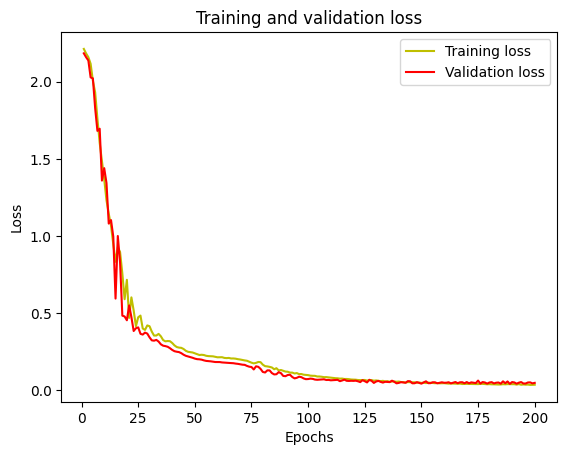

In [21]:
#plot the training and validation accuracy and loss at each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

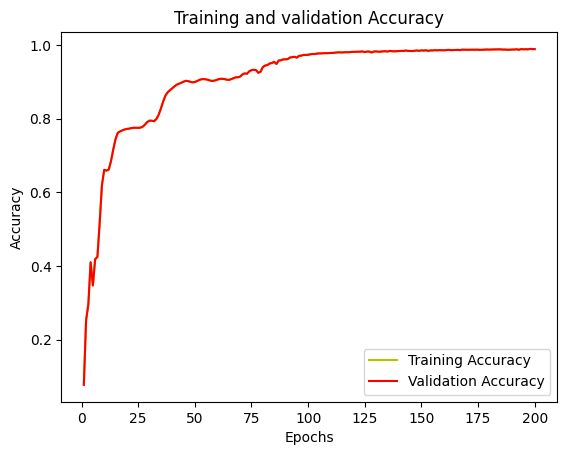

In [22]:

acc = history.history['accuracy']
val_acc = history.history['accuracy']

plt.plot(epochs, acc, 'y', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [23]:
y_pred=model.predict(X_test)
y_pred_argmax=np.argmax(y_pred, axis=3)

1/1 [==============================] - 0s 305ms/step


In [24]:
#Using built in keras function
from keras.metrics import MeanIoU
IOU_keras = MeanIoU(num_classes=n_classes)  
IOU_keras.update_state(y_test[:,:,:,0], y_pred_argmax)
print("Mean IoU =", IOU_keras.result().numpy())


Mean IoU = 0.92843795


IoU for class1 is:  0.9832034
IoU for class2 is:  0.9579167
IoU for class3 is:  0.8441938
IoU for class4 is:  nan


C:\Users\FOIL_member\AppData\Local\Temp\ipykernel_21744\411351157.py:7: RuntimeWarning: invalid value encountered in scalar divide
  class4_IoU = values[3,3]/(values[3,3] + values[3,0] + values[3,1] + values[3,2] + values[0,3]+ values[1,3]+ values[2,3])


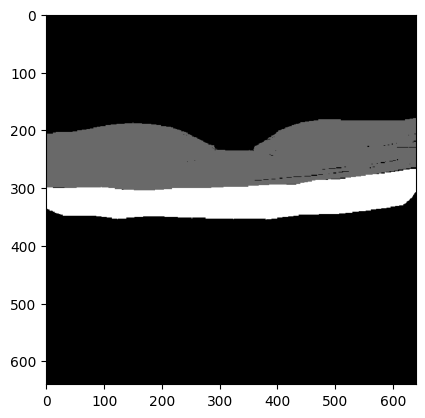

In [25]:
## This is example of IOU of 4 class, if you need provide corresponding amount of class 

values = np.array(IOU_keras.get_weights()).reshape(n_classes, n_classes)
class1_IoU = values[0,0]/(values[0,0] + values[0,1] + values[0,2] + values[0,3] + values[1,0]+ values[2,0]+ values[3,0])
class2_IoU = values[1,1]/(values[1,1] + values[1,0] + values[1,2] + values[1,3] + values[0,1]+ values[2,1]+ values[3,1])
class3_IoU = values[2,2]/(values[2,2] + values[2,0] + values[2,1] + values[2,3] + values[0,2]+ values[1,2]+ values[3,2])
class4_IoU = values[3,3]/(values[3,3] + values[3,0] + values[3,1] + values[3,2] + values[0,3]+ values[1,3]+ values[2,3])


print("IoU for class1 is: ", class1_IoU)
print("IoU for class2 is: ", class2_IoU)
print("IoU for class3 is: ", class3_IoU)
print("IoU for class4 is: ", class4_IoU)

plt.imshow(train_images[0, :,:,0], cmap='gray')
plt.imshow(train_masks[0], cmap='gray')

In [3]:
from tensorflow.keras.models import load_model, save_model

# Assuming model is your Keras model object
#save_model(model, 'RPE_segmentation.keras') 

In [ ]:
# Please start from here
# 1. load the model
# 2. prediction then save the mask

In [4]:
loaded_model = load_model('RPE_segmentation.keras')

1/1 [==============================] - 0s 425ms/step


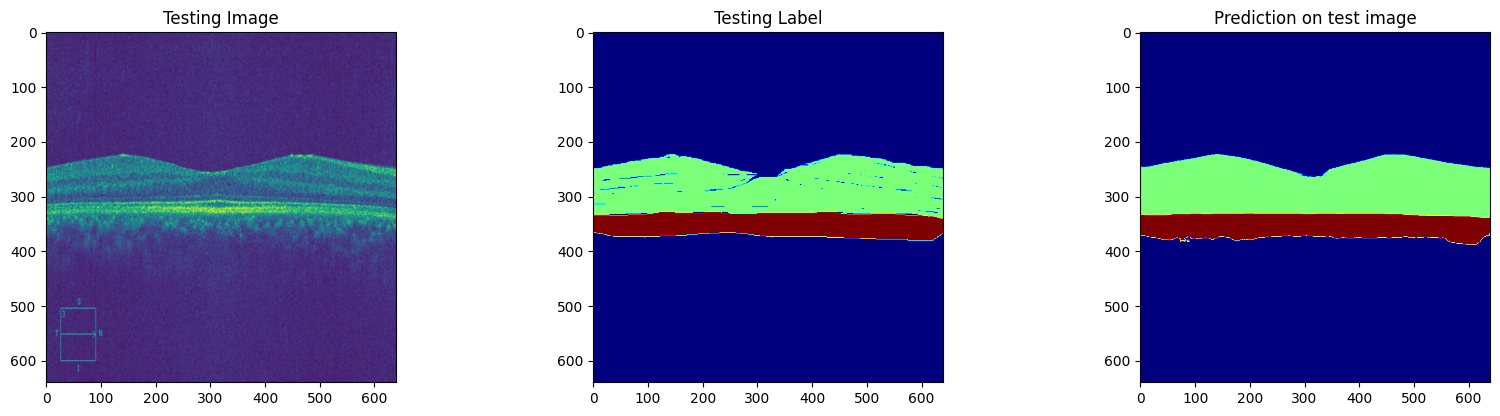

1/1 [==============================] - 0s 368ms/step


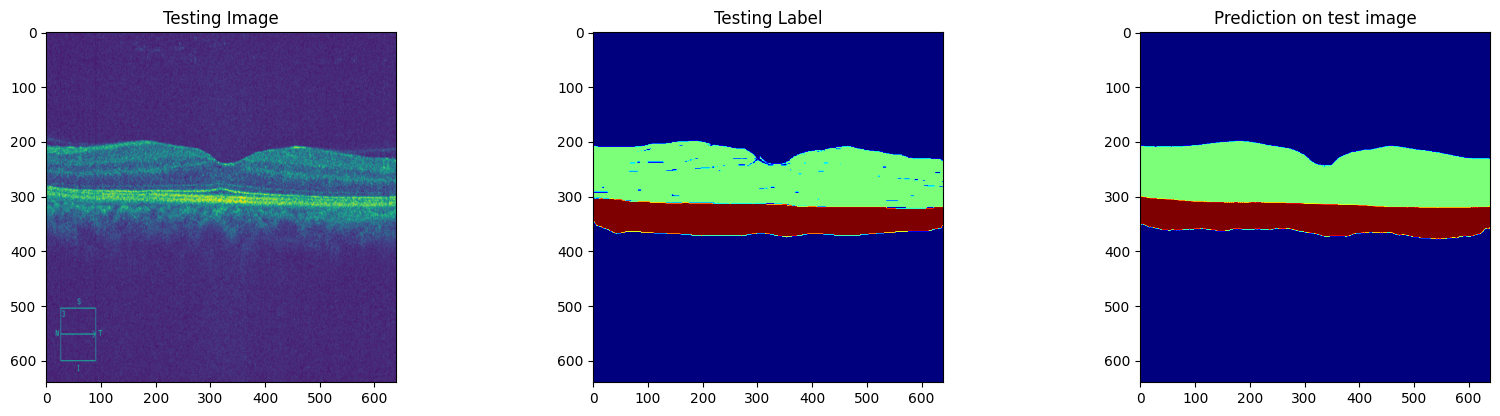

1/1 [==============================] - 0s 425ms/step


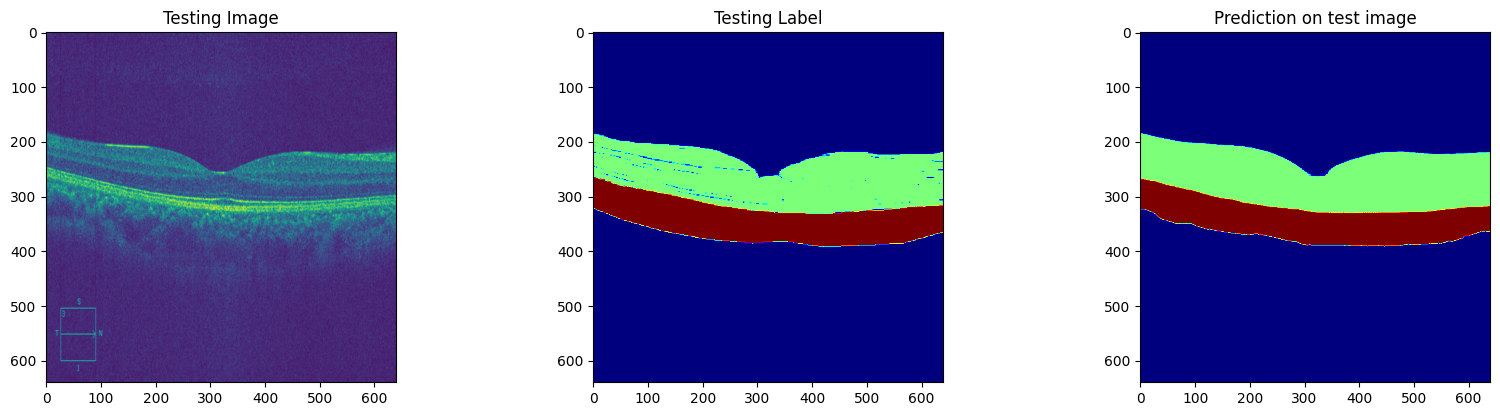

1/1 [==============================] - 0s 358ms/step


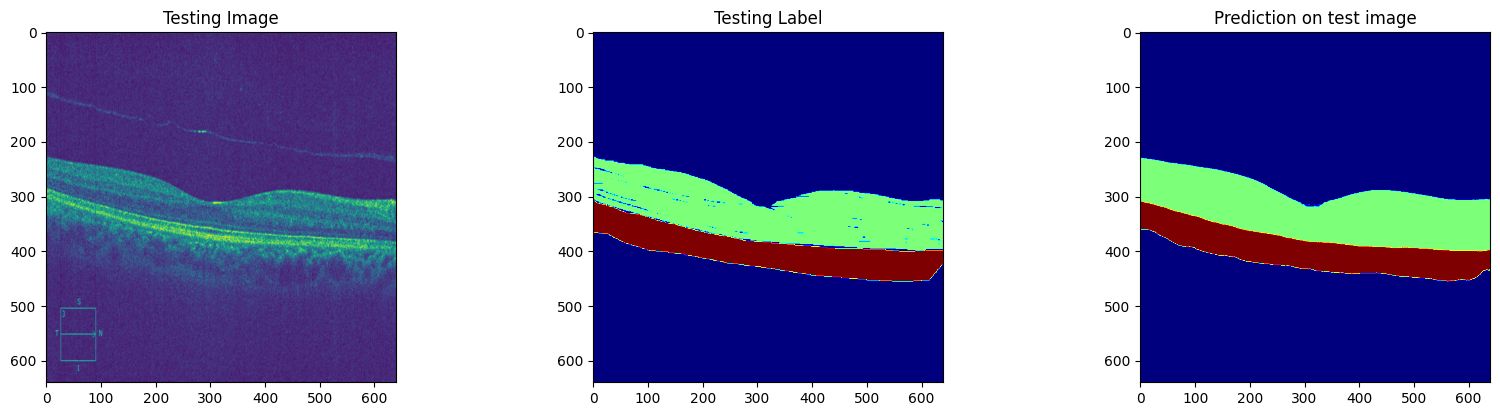

1/1 [==============================] - 0s 386ms/step


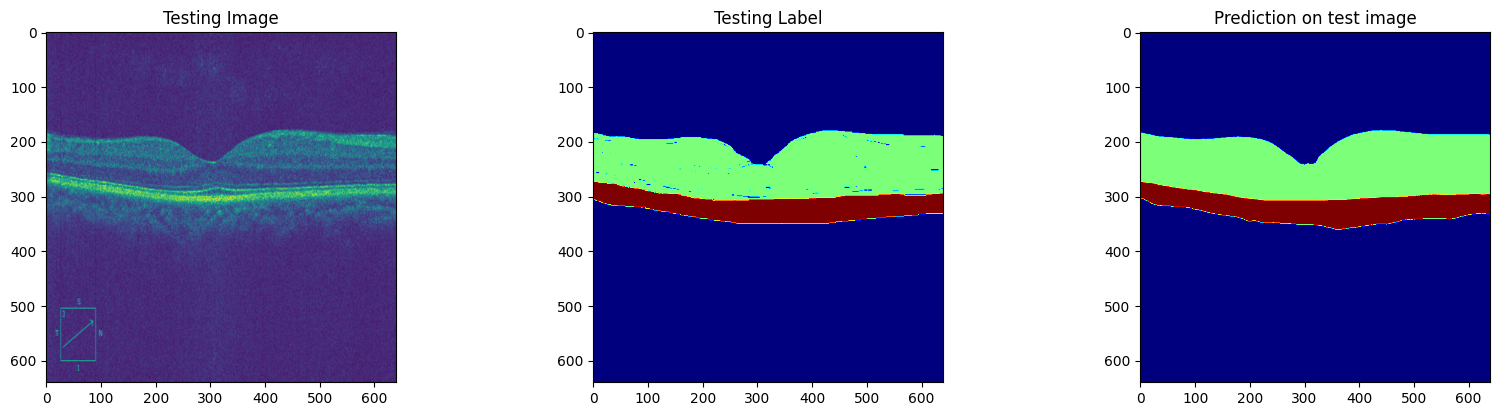

In [14]:
for test_img_number in range(5):
    test_img = X_train[test_img_number]
    ground_truth= y_train[test_img_number]
    test_img_norm=test_img[:,:,0][:,:,None]
    test_img_input=np.expand_dims(test_img_norm, 0)

    prediction = (loaded_model.predict(test_img_input))
    predicted_img = np.argmax(prediction, axis=3)[0,:,:]


    plt.figure(figsize=(20, 10))
    plt.subplot(231)
    plt.title('Testing Image')
    plt.imshow(test_img[:,:,0])
    plt.subplot(232)
    plt.title('Testing Label')
    plt.imshow(ground_truth[:,:,0], cmap='jet')
    plt.subplot(233)
    plt.title('Prediction on test image')
    plt.imshow(predicted_img, cmap='jet')
    plt.show()

1/1 [==============================] - 2s 2s/step

Image 0
Class 0 Dice Coefficient: 0.9926
Class 1 Dice Coefficient: 0.9738
Class 2 Dice Coefficient: 0.9352


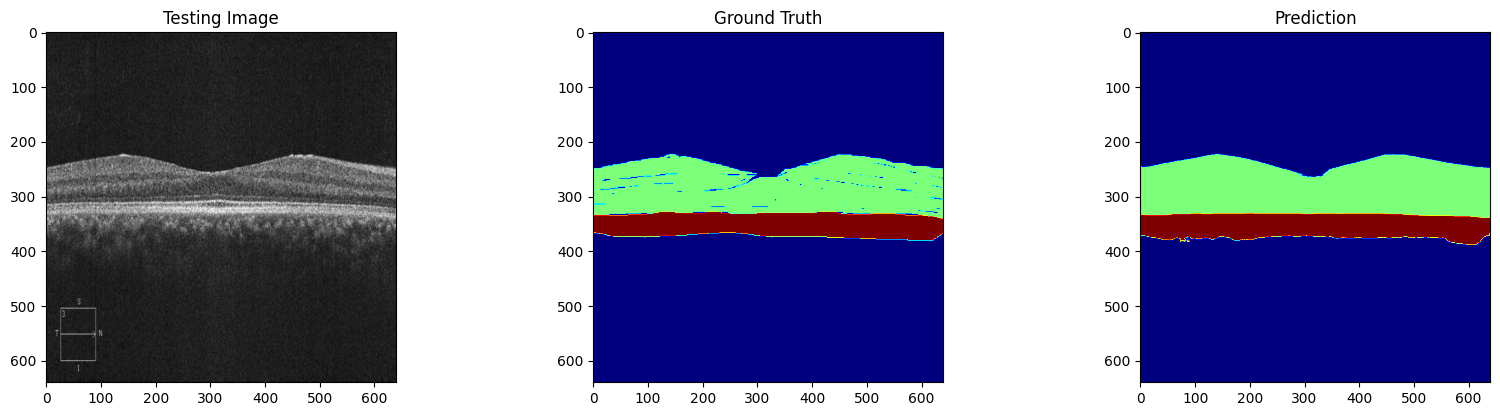

1/1 [==============================] - 2s 2s/step

Image 1
Class 0 Dice Coefficient: 0.9908
Class 1 Dice Coefficient: 0.9840
Class 2 Dice Coefficient: 0.9300


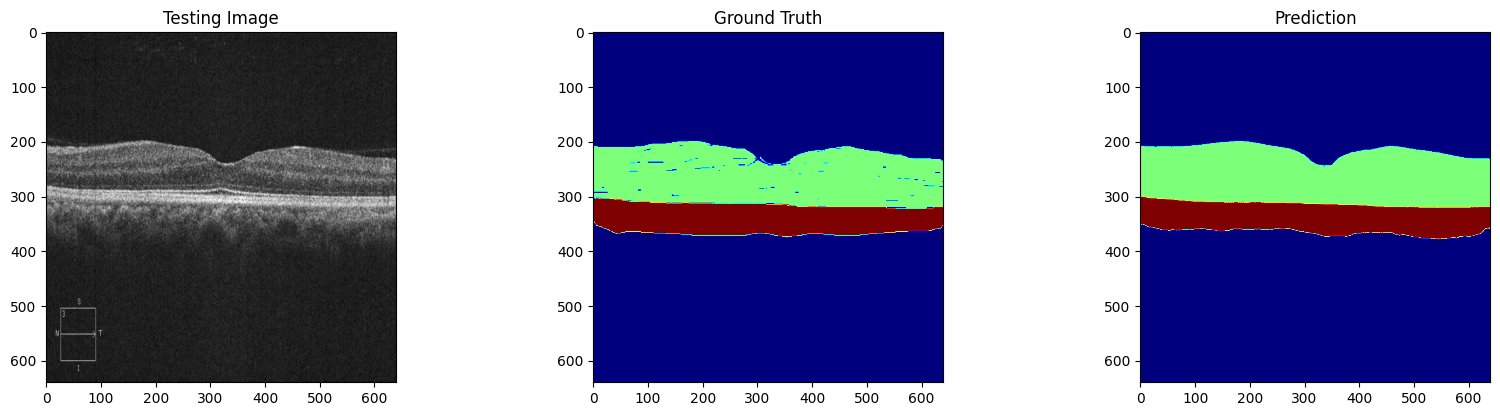

1/1 [==============================] - 2s 2s/step

Image 2
Class 0 Dice Coefficient: 0.9938
Class 1 Dice Coefficient: 0.9776
Class 2 Dice Coefficient: 0.9596


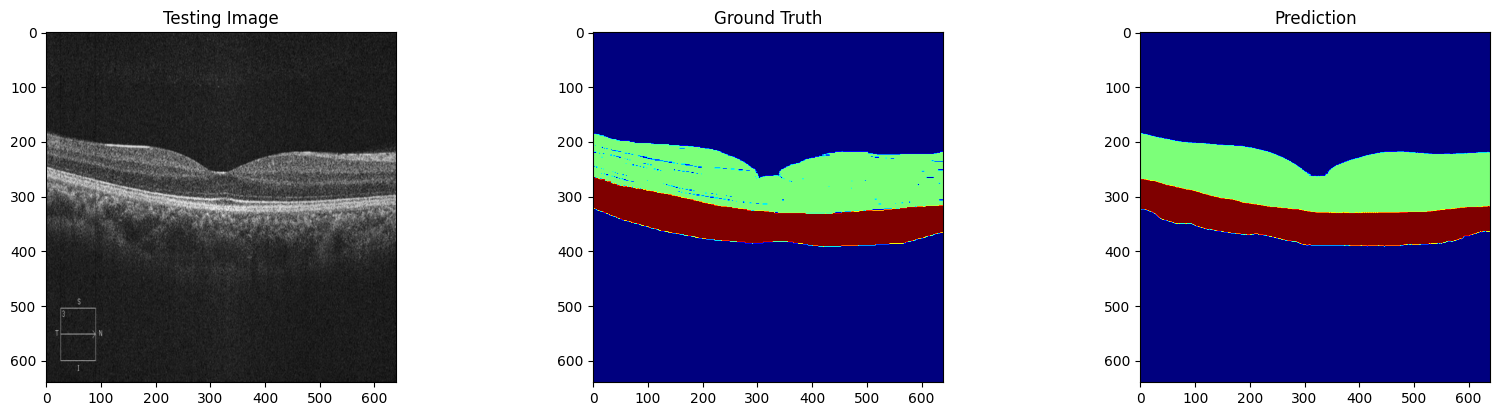

1/1 [==============================] - 2s 2s/step

Image 3
Class 0 Dice Coefficient: 0.9923
Class 1 Dice Coefficient: 0.9803
Class 2 Dice Coefficient: 0.9527


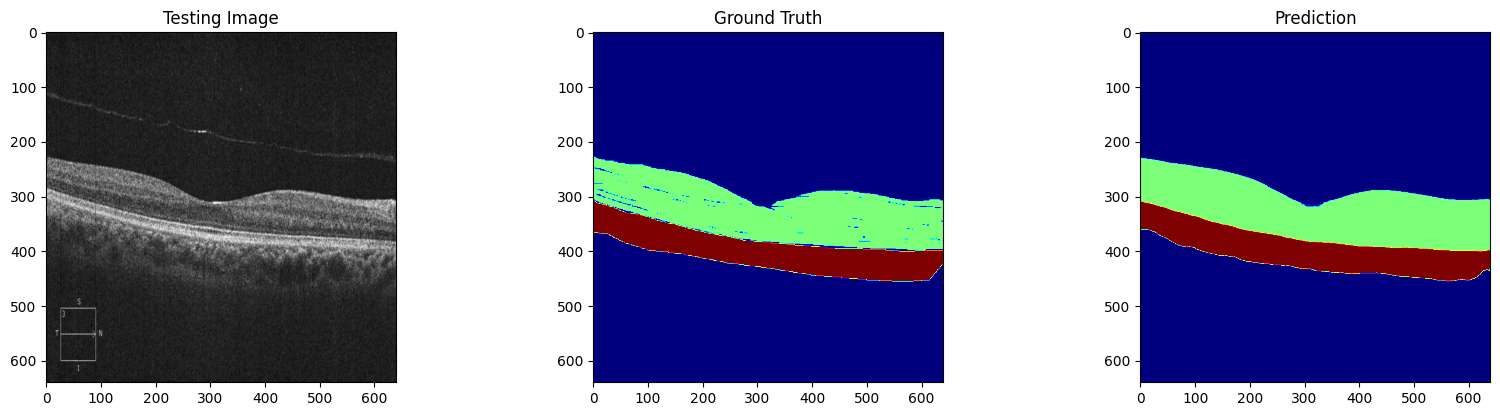

1/1 [==============================] - 2s 2s/step

Image 4
Class 0 Dice Coefficient: 0.9952
Class 1 Dice Coefficient: 0.9860
Class 2 Dice Coefficient: 0.9538


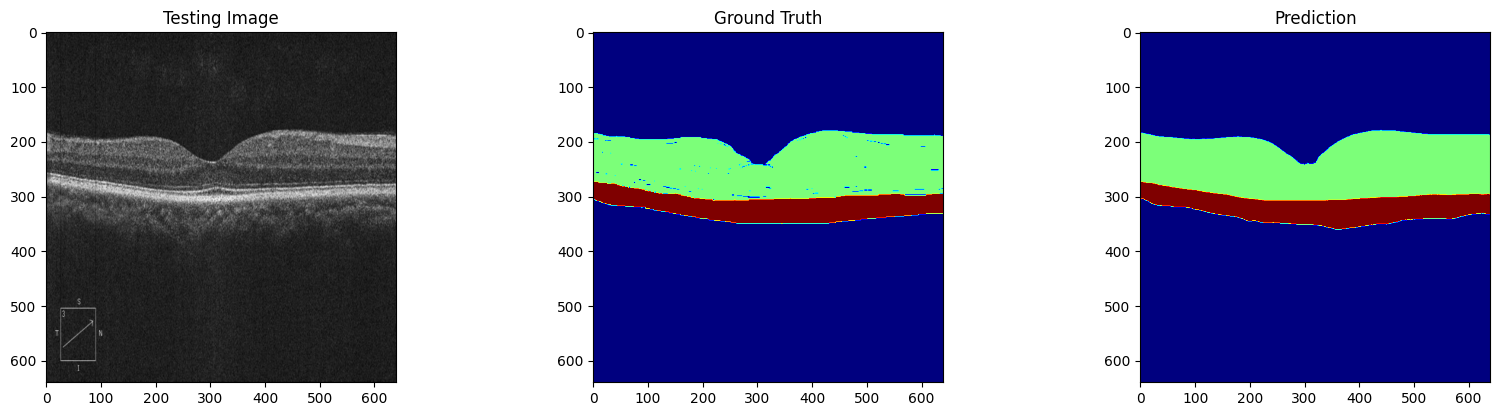

In [ ]:
import numpy as np

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()

    intersection = np.sum(y_true_f * y_pred_f)

    return (2. * intersection + smooth) / (
        np.sum(y_true_f) + np.sum(y_pred_f) + smooth
    )

for test_img_number in range(8):

    test_img = X_train[test_img_number]
    ground_truth = y_train[test_img_number]

    test_img_norm = test_img[:,:,0][:,:,None]
    test_img_input = np.expand_dims(test_img_norm, 0)

    prediction = loaded_model.predict(test_img_input)

    predicted_img = np.argmax(prediction, axis=3)[0,:,:]

    # Ground truth mask
    gt_mask = ground_truth[:,:,0]

    # If multiclass segmentation:
    # compute Dice for each class separately
    classes = np.unique(gt_mask)

    print(f"\nImage {test_img_number}")

    for cls in classes:

        gt_cls = (gt_mask == cls).astype(np.uint8)
        pred_cls = (predicted_img == cls).astype(np.uint8)

        dice = dice_coefficient(gt_cls, pred_cls)

        print(f"Class {cls} Dice Coefficient: {dice:.4f}")

    # Visualization
    plt.figure(figsize=(20, 10))

    plt.subplot(231)
    plt.title('Testing Image')
    plt.imshow(test_img[:,:,0], cmap='gray')

    plt.subplot(232)
    plt.title('Ground Truth')
    plt.imshow(gt_mask, cmap='jet')

    plt.subplot(233)
    plt.title('Prediction')
    plt.imshow(predicted_img, cmap='jet')

    plt.show()

In [ ]:
import os
import glob
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.utils import normalize

def find_topmost_pixels(binary_image):
    # Find contours in the binary image
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Calculate areas for each contour
    areas = [cv2.contourArea(contour) for contour in contours]

    # Find the indices of the largest and second-largest areas
    indices = sorted(range(len(areas)), key=lambda k: areas[k], reverse=True)[:2]

    # Get the largest and second-largest contours
    largest_contour = contours[indices[0]]

    mask_largest = np.zeros_like(binary_image)
    cv2.drawContours(mask_largest, [largest_contour], -1, 255, thickness=cv2.FILLED)

    mask_second_largest = np.zeros_like(binary_image)
    
    if len(contours) > 1:
        second_largest_contour = contours[indices[1]]
        if cv2.contourArea(second_largest_contour) > 0.5*cv2.contourArea(largest_contour):
            cv2.drawContours(mask_second_largest, [second_largest_contour], -1, 255, thickness=cv2.FILLED)

    final_mask = cv2.bitwise_or(mask_largest, mask_second_largest)

    # Display the image with the largest and second-largest contours

    return final_mask

#path for oct images for segmentation
root_paths = [
    #r"G:\Feng\RPE_segmentation\Wills\eye5",
    r"G:\Feng\RPE_segmentation\Topcon003\OD",
    #r"G:\Feng\RPE_segmentation\HongKong\0315A"
]


for root_path in root_paths:

    # Iterate over all folders directly under each root
    for test_path in glob.glob(os.path.join(root_path, "*")):

        if not os.path.isdir(test_path):
            continue

        print("Processing:", test_path)

        test_test = []
        test_filename = []

        # =========================================================
        # Load all PNG images
        # =========================================================
        for img_path in glob.glob(os.path.join(test_path, "*.jpg")):

            # -----------------------------------------------------
            # Exclude generated output files
            # -----------------------------------------------------
            filename_lower = os.path.basename(img_path).lower()

            if img_path.lower().endswith("_mask.png"):
                continue

            if (
                "_probability" in filename_lower
                or "_prediction" in filename_lower
                or "_binary" in filename_lower
                or "_topmost" in filename_lower
                or "_overlay" in filename_lower
                or "_intermediate" in filename_lower
                or "_rnfl_segmentation" in filename_lower
                or "_rpe_segmentation" in filename_lower
            ):
                continue

            # -----------------------------------------------------
            # Read image
            # -----------------------------------------------------
            img = cv2.imread(img_path, 0)

            if img is None:
                print("Could not read:", img_path)
                continue

            # Resize to model input size
            img = cv2.resize(
                img,
                (SIZE_Y, SIZE_X)
            )

            test_test.append(img)
            test_filename.append(img_path)

        # =========================================================
        # Skip folders without images
        # =========================================================
        if len(test_test) == 0:
            print("No PNG images found, skipping.")
            continue

        # =========================================================
        # Convert to numpy array
        # =========================================================
        test_test = np.array(test_test)

        test_test = np.expand_dims(
            test_test,
            axis=3
        )

        test_test = normalize(
            test_test,
            axis=1
        )

        # =========================================================
        # Start timing
        # =========================================================
        starttime = time.time()

        # =========================================================
        # Process all images
        # =========================================================
        for i in range(len(test_test)):

            # =====================================================
            # 1. Original image
            # =====================================================
            original_img = cv2.imread(
                test_filename[i],
                0
            )

            original_img = cv2.resize(
                original_img,
                (SIZE_Y, SIZE_X)
            )

            # =====================================================
            # 2. Prepare model input
            # =====================================================
            test1 = test_test[i]

            test_img_norm = test1[:, :, 0][:, :, None]

            test = np.expand_dims(
                test_img_norm,
                0
            )

            # =====================================================
            # 3. Neural-network prediction
            # =====================================================
            prediction = loaded_model.predict(
                test,
                verbose=0
            )

            # =====================================================
            # 4. Probability maps
            #
            # class 0 = background
            # class 1 = RNFL
            # class 2 = RPE
            # =====================================================
            rnfl_probability = prediction[
                0, :, :, 1
            ]

            rpe_probability = prediction[
                0, :, :, 2
            ]

            # -----------------------------------------------------
            # Convert probability maps to uint8 for saving
            # -----------------------------------------------------
            rnfl_probability_uint8 = (
                np.clip(
                    rnfl_probability,
                    0,
                    1
                ) * 255
            ).astype(np.uint8)

            rpe_probability_uint8 = (
                np.clip(
                    rpe_probability,
                    0,
                    1
                ) * 255
            ).astype(np.uint8)

            # =====================================================
            # 5. Raw class prediction
            # =====================================================
            predicted_class = np.argmax(
                prediction,
                axis=3
            )[0, :, :]

            # =====================================================
            # 6. RNFL segmentation
            # =====================================================
            rnfl_mask = np.zeros(
                predicted_class.shape,
                dtype=np.uint8
            )

            rnfl_mask[
                predicted_class == 1
            ] = 255

            # =====================================================
            # 7. RPE segmentation
            # =====================================================
            rpe_mask = np.zeros(
                predicted_class.shape,
                dtype=np.uint8
            )

            rpe_mask[
                predicted_class == 2
            ] = 255

            # =====================================================
            # 8. Combined U-Net prediction display
            #
            # Background = 0
            # RNFL       = 125
            # RPE        = 255
            # =====================================================
            prediction_display = np.zeros(
                predicted_class.shape,
                dtype=np.uint8
            )

            prediction_display[
                predicted_class == 1
            ] = 125

            prediction_display[
                predicted_class == 2
            ] = 255

            # =====================================================
            # 9. Extract topmost RPE pixels
            # =====================================================
            final_mask = find_topmost_pixels(
                rpe_mask
            )

            # =====================================================
            # 10. Final segmentation output
            #
            # Keep RNFL region = 125
            # Replace RPE region with RPE boundary = 255
            # =====================================================
            predicted_img = prediction_display.copy()

            # Remove filled RPE segmentation
            predicted_img[
                predicted_img == 255
            ] = 0

            # Add final RPE boundary
            predicted_img[
                final_mask == 255
            ] = 255

            # Resize final output
            predicted_img_resized = cv2.resize(
                predicted_img,
                (200, 1024),
                interpolation=cv2.INTER_NEAREST
            )

            # =====================================================
            # 11. Create final overlay with 50% opacity
            # =====================================================
            overlay = cv2.cvtColor(
                original_img,
                cv2.COLOR_GRAY2BGR
            )

            alpha = 0.5

            # -----------------------------------------------------
            # RNFL segmentation = green, 50% opacity
            # -----------------------------------------------------
            rnfl_idx = rnfl_mask == 255

            overlay[rnfl_idx] = (
                (1 - alpha) * overlay[rnfl_idx]
                + alpha * np.array([0, 255, 0])
            ).astype(np.uint8)


            # -----------------------------------------------------
            # Final RPE boundary = red, 50% opacity
            # -----------------------------------------------------
            rpe_idx = final_mask == 255

            overlay[rpe_idx] = (
                (1 - alpha) * overlay[rpe_idx]
                + alpha * np.array([0, 0, 255])
            ).astype(np.uint8)

            # =====================================================
            # 12. Output filenames
            # =====================================================
            base_filename = os.path.splitext(
                test_filename[i]
            )[0]

            mask_filename = (
                base_filename
                + "_mask.png"
            )

            rnfl_probability_filename = (
                base_filename
                + "_RNFL_probability.png"
            )

            rpe_probability_filename = (
                base_filename
                + "_RPE_probability.png"
            )

            rnfl_segmentation_filename = (
                base_filename
                + "_RNFL_segmentation.png"
            )

            rpe_segmentation_filename = (
                base_filename
                + "_RPE_segmentation.png"
            )

            prediction_filename = (
                base_filename
                + "_prediction.png"
            )

            topmost_filename = (
                base_filename
                + "_topmost.png"
            )

            overlay_filename = (
                base_filename
                + "_overlay.png"
            )

            combined_filename = (
                base_filename
                + "_intermediate.png"
            )

            # =====================================================
            # 13. Save individual results
            # =====================================================

            # Final mask
            cv2.imwrite(
                mask_filename,
                predicted_img_resized
            )

            # RNFL probability
            cv2.imwrite(
                rnfl_probability_filename,
                rnfl_probability_uint8
            )

            # RPE probability
            cv2.imwrite(
                rpe_probability_filename,
                rpe_probability_uint8
            )

            # RNFL segmentation
            cv2.imwrite(
                rnfl_segmentation_filename,
                rnfl_mask
            )

            # RPE segmentation
            cv2.imwrite(
                rpe_segmentation_filename,
                rpe_mask
            )

            # Combined raw U-Net prediction
            cv2.imwrite(
                prediction_filename,
                prediction_display
            )

            # Final RPE boundary
            cv2.imwrite(
                topmost_filename,
                final_mask
            )

            # Overlay
            cv2.imwrite(
                overlay_filename,
                overlay
            )

            # =====================================================
            # 14. Create combined intermediate figure
            # =====================================================
            fig, axes = plt.subplots(
                1,
                7,
                figsize=(28, 5)
            )

            # -----------------------------------------------------
            # Panel 1: Original OCT
            # -----------------------------------------------------
            axes[0].imshow(
                original_img,
                cmap="gray"
            )

            axes[0].set_title(
                "Original OCT",
                fontsize=14
            )

            # -----------------------------------------------------
            # Panel 2: RNFL probability
            # -----------------------------------------------------
            im1 = axes[1].imshow(
                rnfl_probability,
                cmap="jet",
                vmin=0,
                vmax=1
            )

            axes[1].set_title(
                "RNFL Probability",
                fontsize=14
            )

            cbar1 = fig.colorbar(
                im1,
                ax=axes[1],
                fraction=0.046,
                pad=0.04
            )

            cbar1.set_label(
                "Probability",
                fontsize=11
            )

            cbar1.set_ticks([
                0,
                0.25,
                0.50,
                0.75,
                1.00
            ])

            cbar1.ax.tick_params(
                labelsize=9
            )

            # -----------------------------------------------------
            # Panel 3: RNFL segmentation
            # -----------------------------------------------------
            axes[2].imshow(
                rnfl_mask,
                cmap="gray",
                vmin=0,
                vmax=255
            )

            axes[2].set_title(
                "RNFL Segmentation",
                fontsize=14
            )

            # -----------------------------------------------------
            # Panel 4: RPE probability
            # -----------------------------------------------------
            im2 = axes[3].imshow(
                rpe_probability,
                cmap="jet",
                vmin=0,
                vmax=1
            )

            axes[3].set_title(
                "RPE Probability",
                fontsize=14
            )

            cbar2 = fig.colorbar(
                im2,
                ax=axes[3],
                fraction=0.046,
                pad=0.04
            )

            cbar2.set_label(
                "Probability",
                fontsize=11
            )

            cbar2.set_ticks([
                0,
                0.25,
                0.50,
                0.75,
                1.00
            ])

            cbar2.ax.tick_params(
                labelsize=9
            )

            # -----------------------------------------------------
            # Panel 5: RPE segmentation
            # -----------------------------------------------------
            axes[4].imshow(
                rpe_mask,
                cmap="gray",
                vmin=0,
                vmax=255
            )

            axes[4].set_title(
                "RPE Segmentation",
                fontsize=14
            )

            # -----------------------------------------------------
            # Panel 6: U-Net prediction
            # -----------------------------------------------------
            axes[5].imshow(
                prediction_display,
                cmap="gray",
                vmin=0,
                vmax=255
            )

            axes[5].set_title(
                "U-Net Prediction",
                fontsize=14
            )

            # -----------------------------------------------------
            # Panel 7: Final segmentation overlay
            # -----------------------------------------------------
            axes[6].imshow(
                cv2.cvtColor(
                    overlay,
                    cv2.COLOR_BGR2RGB
                )
            )

            axes[6].set_title(
                "Final Segmentation",
                fontsize=14
            )

            # -----------------------------------------------------
            # Remove axes
            # -----------------------------------------------------
            for ax in axes:
                ax.axis("off")

            plt.tight_layout()

            # -----------------------------------------------------
            # Save combined intermediate figure
            # -----------------------------------------------------
            plt.savefig(
                combined_filename,
                dpi=200,
                bbox_inches="tight"
            )

            plt.close(fig)

        # =========================================================
        # End timing
        # =========================================================
        endtime = time.time()

        print(
            f"Finished {len(test_test)} images in "
            f"{endtime - starttime:.2f} seconds"
        )

Processing: G:\Feng\RPE_segmentation\Topcon003\OD\586
Finished 363 images in 1032.81 seconds
Processing: G:\Feng\RPE_segmentation\Topcon003\OD\588
Finished 363 images in 932.47 seconds
Processing: G:\Feng\RPE_segmentation\Topcon003\OD\590
Finished 363 images in 1280.98 seconds
Processing: G:\Feng\RPE_segmentation\Topcon003\OD\591
Finished 363 images in 1692.98 seconds
Processing: G:\Feng\RPE_segmentation\Topcon003\OD\593
Finished 363 images in 2061.95 seconds
Processing: G:\Feng\RPE_segmentation\Topcon003\OD\595
Finished 363 images in 2461.08 seconds
Processing: G:\Feng\RPE_segmentation\Topcon003\OD\597
Finished 363 images in 3386.28 seconds
Processing: G:\Feng\RPE_segmentation\Topcon003\OD\599
Finished 363 images in 3811.46 seconds
Processing: G:\Feng\RPE_segmentation\Topcon003\OD\601
Finished 363 images in 5069.78 seconds
Processing: G:\Feng\RPE_segmentation\Topcon003\OD\603
Finished 363 images in 5523.27 seconds
Processing: G:\Feng\RPE_segmentation\Topcon003\OD\605
Finished 363 imag

In [86]:
import cv2

def find_topmost_pixels(binary_image):
    # Find contours in the binary image
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Calculate areas for each contour
    areas = [cv2.contourArea(contour) for contour in contours]

    # Find the indices of the largest and second-largest areas
    indices = sorted(range(len(areas)), key=lambda k: areas[k], reverse=True)[:2]

    # Get the largest and second-largest contours
    largest_contour = contours[indices[0]]

    mask_largest = np.zeros_like(binary_image)
    cv2.drawContours(mask_largest, [largest_contour], -1, 255, thickness=cv2.FILLED)

    mask_second_largest = np.zeros_like(binary_image)
    
    if len(contours) > 1:
        second_largest_contour = contours[indices[1]]
        if cv2.contourArea(second_largest_contour) > 0.5*cv2.contourArea(largest_contour):
            cv2.drawContours(mask_second_largest, [second_largest_contour], -1, 255, thickness=cv2.FILLED)

    final_mask = cv2.bitwise_or(mask_largest, mask_second_largest)

    # Display the image with the largest and second-largest contours

    return final_mask

    
    

for i in range(200):
    test1 = test_test[i]
    test_img_norm=test1[:,:,0][:,:,None]
    test=np.expand_dims(test_img_norm, 0)

    prediction = (model.predict(test))
    predicted_img = np.argmax(prediction, axis=3)[0,:,:]
    predicted_img[predicted_img==1] = 125
    predicted_img[predicted_img==2] = 255
    
    _, binary_image = cv2.threshold(predicted_img.astype(np.uint8), 200, 255, cv2.THRESH_BINARY)
    
    final_mask = find_topmost_pixels(binary_image)
    predicted_img[predicted_img==255] = 0
    predicted_img[final_mask==255] = 255
    predicted_img = cv2.resize(predicted_img.astype(float),(200,1024))
    cv2.imwrite(test_filename[i].split('.tif')[0]+'_mask.png',predicted_img)
    print(i)
    # plt.imshow(prediction[0,:,:,7], cmap='jet')


1/1 [==============================] - 0s 365ms/step
0
1/1 [==============================] - 0s 356ms/step
1
1/1 [==============================] - 0s 358ms/step
2
1/1 [==============================] - 0s 378ms/step
3
1/1 [==============================] - 0s 365ms/step
4
1/1 [==============================] - 0s 367ms/step
5
1/1 [==============================] - 0s 353ms/step
6
1/1 [==============================] - 0s 352ms/step
7
1/1 [==============================] - 0s 371ms/step
8
1/1 [==============================] - 0s 350ms/step
9
1/1 [==============================] - 0s 362ms/step
10
1/1 [==============================] - 0s 353ms/step
11
1/1 [==============================] - 0s 367ms/step
12
1/1 [==============================] - 0s 366ms/step
13
1/1 [==============================] - 0s 356ms/step
14
1/1 [==============================] - 0s 365ms/step
15
1/1 [==============================] - 0s 354ms/step
16
1/1 [==============================] - 0s 360ms/step
17
1/

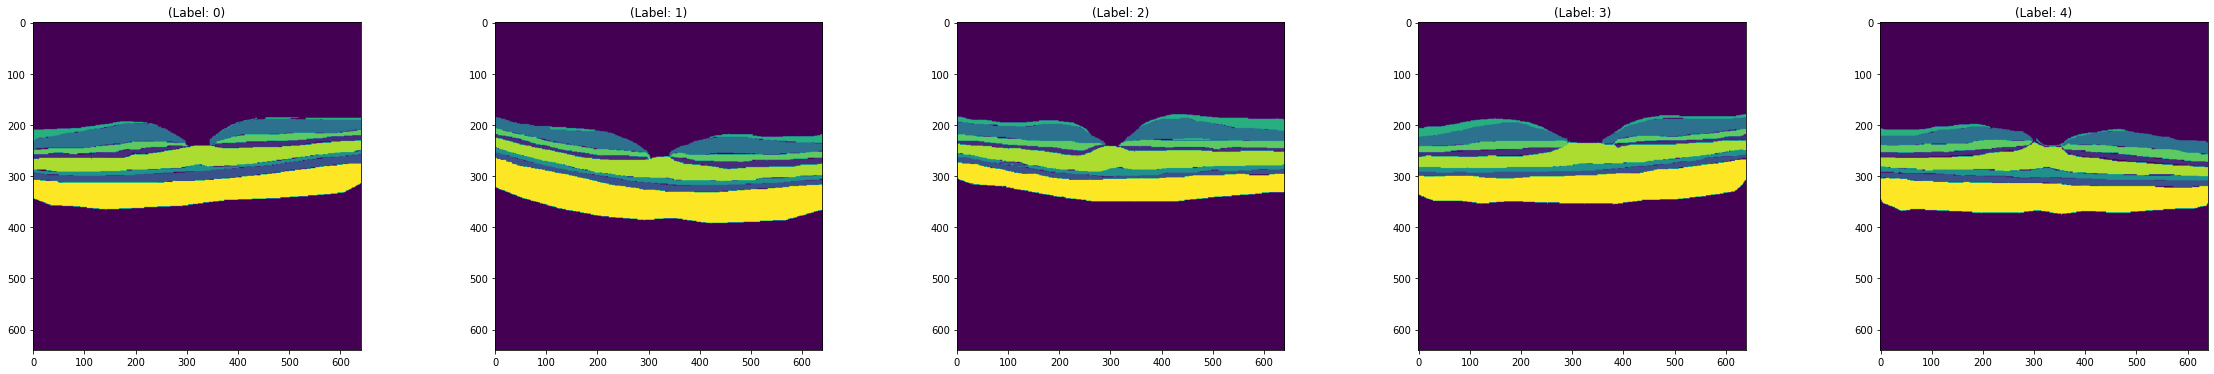

In [66]:
plt.figure(figsize=(40,100))
# print("Оригинал изображений")
for i in range(5):
    plt.subplot(14, 5, i+1)
    plt.imshow(y_train[i,:,:])
    # curr_lbl = X_test[i]
    plt.title("(Label: " + str(i) + ")")
plt.show()   

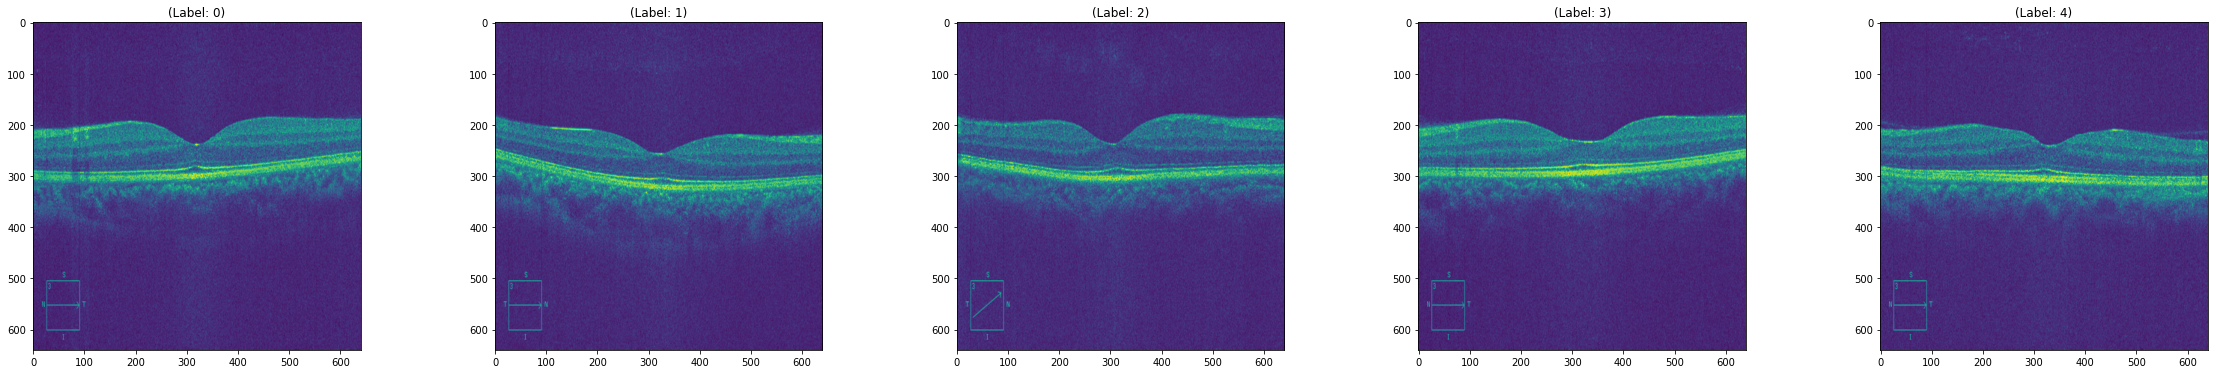

In [67]:
plt.figure(figsize=(40,100))
# print("Оригинал изображений")
for i in range(5):
    plt.subplot(14, 5, i+1)
    plt.imshow(X_train[i,:,:])
    # curr_lbl = X_test[i]
    plt.title("(Label: " + str(i) + ")")
plt.show()   

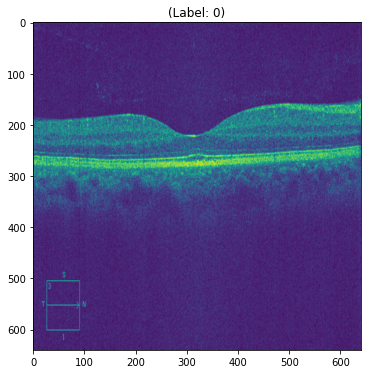

In [68]:
plt.figure(figsize=(40,100))
# print("Оригинал изображений")
for i in range(1):
    plt.subplot(14, 5, i+1)
    plt.imshow(X_test[i,:,:])
    # curr_lbl = X_test[i]
    plt.title("(Label: " + str(i) + ")")
plt.show()   

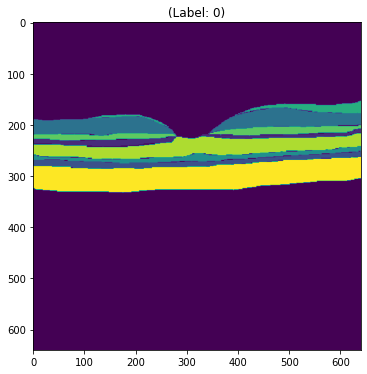

In [69]:
plt.figure(figsize=(40,100))
# print("Оригинал изображений")
for i in range(1):
    plt.subplot(14, 5, i+1)
    plt.imshow(y_test[i,:,:])
    # curr_lbl = X_test[i]
    plt.title("(Label: " + str(i) + ")")
plt.show()   